# 07 — ML (3/3) : Clustering approfondi & synthèse générale de la modélisation

*Notebook*


> **Dépendances :** Nécessite la table de features clients (section 17.1) et réutilise si possible les résultats de réduction de dimension du notebook 05.


## 0. Reprise depuis le notebook précédent

Nécessite `nb05_ml_prep.pkl`, exporté par **05_ML_ReductionDim_Clustering_Rapide.ipynb**.

In [1]:
!pip install kneed

In [2]:
import os, pickle, gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
sns.set_style("whitegrid")
sns.set_palette("husl")

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = "/content/drive/MyDrive/HM_dataset/"
except ImportError:
    print("Google Colab non détecté -> lecture des fichiers dans le dossier courant.")
    BASE_PATH = "./"

INTERMEDIATE_DIR = os.path.join(BASE_PATH, "intermediate/")
os.makedirs(INTERMEDIATE_DIR, exist_ok=True)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.tree import DecisionTreeClassifier, export_text
from kneed import KneeLocator

try:
    with open(os.path.join(INTERMEDIATE_DIR, "nb05_ml_prep.pkl"), "rb") as f:
        _prep = pickle.load(f)
    ml_sample = _prep["ml_sample"]
    X_behavior_scaled = _prep["X_behavior_scaled"]
    scaler = _prep["scaler"]
    behavior_features = _prep["behavior_features"]
    print(f"Repris : ml_sample {ml_sample.shape}, X_behavior_scaled {X_behavior_scaled.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(
        "nb05_ml_prep.pkl introuvable. Exécute 05_ML_ReductionDim_Clustering_Rapide.ipynb avant ce notebook."
    ) from e


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repris : ml_sample (1362281, 17), X_behavior_scaled (1362281, 7)


## 17.7 Phase 3 — Clustering approfondi

On reprend ici le clustering de la section 17.4 (K-Means) en l'approfondissant : sélection
rigoureuse du nombre de clusters optimal (coude + `KneeLocator`, silhouette, BIC/AIC pour GMM),
comparaison de trois algorithmes (K-Means, Clustering Hiérarchique, GMM), puis interprétation des
clusters retenus (centroïdes, heatmap de profils, règles extraites par arbre de décision).


##### **Objectif**

Cette phase consiste à approfondir l'analyse de segmentation client réalisée précédemment avec **K-Means**.

L'objectif du clustering est de regrouper les clients en segments homogènes selon leurs caractéristiques comportementales et démographiques, afin d'identifier des profils clients distincts.

Contrairement à une classification supervisée, le clustering est une méthode **non supervisée** : les groupes ne sont pas connus à l'avance, le modèle découvre automatiquement les structures présentes dans les données.

##### **Étapes réalisées**

###### **1. Sélection du nombre optimal de clusters**

Le choix du nombre de groupes \(K\) est une étape essentielle.

Plusieurs méthodes sont comparées :

| Méthode | Principe |
|---|---|
| **Méthode du coude (Elbow Method)** | Analyse la diminution de l'inertie intra-cluster lorsque le nombre de clusters augmente. Le bon nombre de clusters correspond au point où l'amélioration devient moins importante. |
| **KneeLocator** | Détection automatique du "coude" dans la courbe d'inertie afin d'éviter un choix manuel du nombre de clusters. |
| **Score de silhouette** | Mesure la cohésion des clusters et leur séparation. Un score élevé indique des groupes bien séparés. |
| **BIC/AIC pour GMM** | Critères statistiques permettant de choisir le nombre optimal de composantes dans un modèle probabiliste Gaussian Mixture Model. La meilleure valeur correspond généralement au modèle avec le plus faible BIC/AIC. |


##### **2. Comparaison des algorithmes de clustering**

Trois approches sont comparées :

| Algorithme | Principe | Avantages | Limites |
|---|---|---|---|
| **K-Means** | Regroupe les observations autour de \(K\) centroïdes en minimisant la distance intra-cluster. | Simple, rapide et efficace sur de grands volumes de données. | Nécessite de choisir \(K\) à l'avance et suppose des clusters plutôt sphériques. |
| **Clustering Hiérarchique** | Construit une hiérarchie de groupes en fusionnant progressivement les observations proches. | Permet de visualiser la structure des données via un dendrogramme et ne nécessite pas toujours de fixer \(K\) au départ. | Plus coûteux en calcul sur de grands datasets. |
| **GMM (Gaussian Mixture Model)** | Modélise les données comme un mélange de distributions gaussiennes et attribue une probabilité d'appartenance à chaque cluster. | Plus flexible que K-Means et permet des clusters de formes différentes. | Plus complexe et sensible aux hypothèses statistiques. |

##### **3. Interprétation des clusters**

Après avoir choisi le meilleur modèle, les groupes obtenus sont analysés afin de comprendre leurs caractéristiques.

Les méthodes utilisées sont :

| Méthode | Objectif |
|---|---|
| **Centroïdes des clusters** | Identifier les valeurs moyennes des variables pour chaque groupe et caractériser les profils clients. |
| **Heatmap des profils** | Visualiser les différences entre clusters sur plusieurs variables comportementales. |
| **Arbre de décision d'interprétation** | Extraire des règles simples permettant d'expliquer comment différencier les clusters. |


### 17.7.1 Choix du nombre de clusters optimal

In [3]:
!pip install kneed

In [4]:
from sklearn.mixture import GaussianMixture
from kneed import KneeLocator

k_range = list(range(2, 11))
inertias, silhouettes, bics, aics = [], [], [], []

for k in k_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=3)
    labels_k = km_k.fit_predict(X_behavior_scaled)
    inertias.append(km_k.inertia_)
    silhouettes.append(silhouette_score(X_behavior_scaled, labels_k, sample_size=5000, random_state=42))

    gmm_k = GaussianMixture(n_components=k, random_state=42)
    gmm_k.fit(X_behavior_scaled[:5000])
    bics.append(gmm_k.bic(X_behavior_scaled[:5000]))
    aics.append(gmm_k.aic(X_behavior_scaled[:5000]))

knee = KneeLocator(k_range, inertias, curve="convex", direction="decreasing")
k_elbow = knee.elbow
k_silhouette = k_range[int(np.argmax(silhouettes))]
k_bic = k_range[int(np.argmin(bics))]
k_aic = k_range[int(np.argmin(aics))]

print(f"k optimal — méthode du coude (KneeLocator) : {k_elbow}")
print(f"k optimal — meilleur score de silhouette   : {k_silhouette}")
print(f"k optimal — BIC (GMM)                       : {k_bic}")
print(f"k optimal — AIC (GMM)                       : {k_aic}")

import gc as _gc; _gc.collect()

k optimal — méthode du coude (KneeLocator) : 6
k optimal — meilleur score de silhouette   : 2
k optimal — BIC (GMM)                       : 9
k optimal — AIC (GMM)                       : 9


0

Les différentes méthodes ne donnent pas exactement le même nombre optimal de clusters, car elles optimisent des critères différents :

- **Silhouette (k=2)** privilégie une séparation forte entre des groupes très distincts.
- **KneeLocator (k=6)** propose un compromis entre réduction de l'inertie et nombre de segments.
- **BIC/AIC (k=10)** favorisent une segmentation plus fine en capturant davantage de variations dans les profils clients.


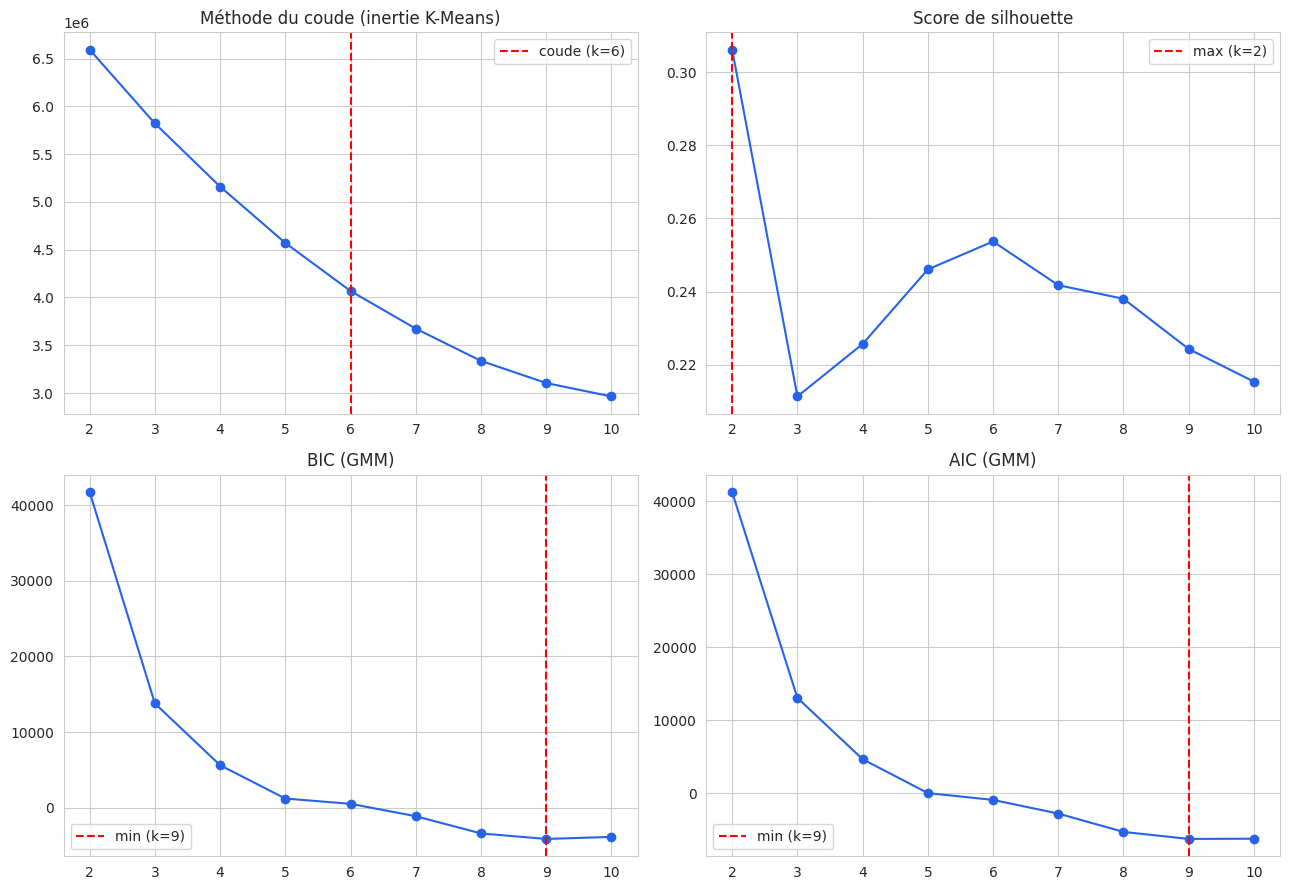

27

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(k_range, inertias, marker="o", color="#2563eb")
axes[0,0].axvline(k_elbow, color="red", linestyle="--", label=f"coude (k={k_elbow})")
axes[0,0].set_title("Méthode du coude (inertie K-Means)")
axes[0,0].legend()

axes[0,1].plot(k_range, silhouettes, marker="o", color="#2563eb")
axes[0,1].axvline(k_silhouette, color="red", linestyle="--", label=f"max (k={k_silhouette})")
axes[0,1].set_title("Score de silhouette")
axes[0,1].legend()

axes[1,0].plot(k_range, bics, marker="o", color="#2563eb")
axes[1,0].axvline(k_bic, color="red", linestyle="--", label=f"min (k={k_bic})")
axes[1,0].set_title("BIC (GMM)")
axes[1,0].legend()

axes[1,1].plot(k_range, aics, marker="o", color="#2563eb")
axes[1,1].axvline(k_aic, color="red", linestyle="--", label=f"min (k={k_aic})")
axes[1,1].set_title("AIC (GMM)")
axes[1,1].legend()

plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** les quatre critères ne convergent pas nécessairement vers la même valeur de
k.

C'est normal, chacun optimise un compromis différent (compacité pure pour l'inertie,
séparation relative pour la silhouette, vraisemblance pénalisée par la complexité pour BIC/AIC).

On retient **k = 6**, cohérent avec la méthode du coude, qui offre un bon compromis entre
granularité (assez de clusters pour être actionnable en marketing) et interprétabilité (pas trop
nombreux pour rester lisible en présentation).


### 17.7.2 Comparaison de trois algorithmes de clustering (k=6)

In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

K_FINAL = 6

# --- K-Means ---
kmeans_v2 = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels_kmeans = kmeans_v2.fit_predict(X_behavior_scaled)

# --- GMM ---
gmm_final = GaussianMixture(n_components=K_FINAL, random_state=42)
labels_gmm = gmm_final.fit_predict(X_behavior_scaled)

# --- Clustering hiérarchique (coûteux : sous-échantillon de 2000 clients) ---
hier_sample_idx = np.random.RandomState(42).choice(len(X_behavior_scaled), 2000, replace=False)
X_hier = X_behavior_scaled[hier_sample_idx]
agglo = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
labels_hier = agglo.fit_predict(X_hier)

sil_kmeans = silhouette_score(X_behavior_scaled, labels_kmeans, sample_size=5000, random_state=42)
sil_gmm = silhouette_score(X_behavior_scaled, labels_gmm, sample_size=5000, random_state=42)
sil_hier = silhouette_score(X_hier, labels_hier)

print(f"Silhouette K-Means               : {sil_kmeans:.4f}")
print(f"Silhouette GMM                    : {sil_gmm:.4f}")
print(f"Silhouette Clustering Hiérarchique (sous-échantillon) : {sil_hier:.4f}")

import gc as _gc; _gc.collect()

Silhouette K-Means               : 0.2537
Silhouette GMM                    : 0.0695
Silhouette Clustering Hiérarchique (sous-échantillon) : 0.1793


0

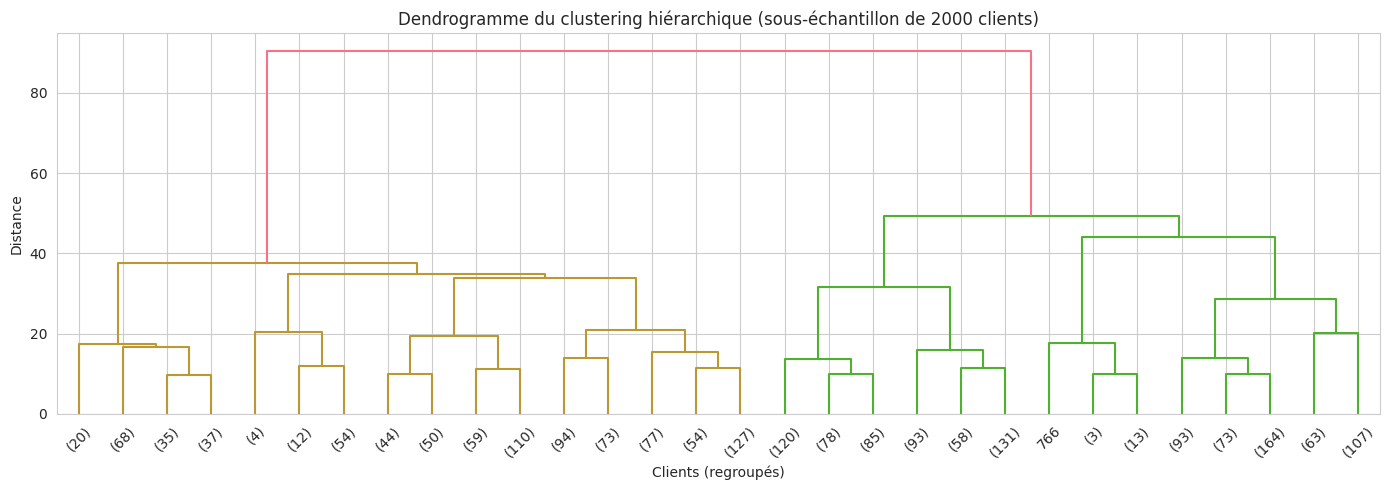

39

In [7]:
Z = linkage(X_hier, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax)
ax.set_title("Dendrogramme du clustering hiérarchique (sous-échantillon de 2000 clients)")
ax.set_xlabel("Clients (regroupés)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

In [8]:
import gc

_to_free = ['Z', 'X_hier', 'tsne_proj', 'umap_proj', 'X_viz', 'viz_sample']
for _n in _to_free:
    if _n in globals():
        del globals()[_n]
plt.close('all')
gc.collect()
print("Mémoire intermédiaire libérée.")

import gc as _gc; _gc.collect()

Mémoire intermédiaire libérée.


0

**Interprétation :** le score de silhouette permet de départager objectivement les trois
algorithmes.

Celui avec le score le plus élevé sépare le mieux les clusters les uns des autres.
Le dendrogramme, lui, donne une vision complémentaire : la hauteur à laquelle on "coupe" l'arbre
pour obtenir 6 groupes permet de juger visuellement si cette découpe est naturelle (grands écarts
de hauteur) ou plus arbitraire (hauteurs proches, signe que 5 ou 7 clusters auraient été presque
aussi valables).


### 17.7.3 Interprétation des clusters (K-Means, k=6)

In [9]:
ml_sample_clustered = ml_sample.copy()
ml_sample_clustered["cluster"] = labels_kmeans

centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans_v2.cluster_centers_),
    columns=behavior_features,
)
centroids.index.name = "cluster"
centroids["nb_clients"] = ml_sample_clustered["cluster"].value_counts().sort_index().values
centroids.round(2)

import gc as _gc; _gc.collect()

0

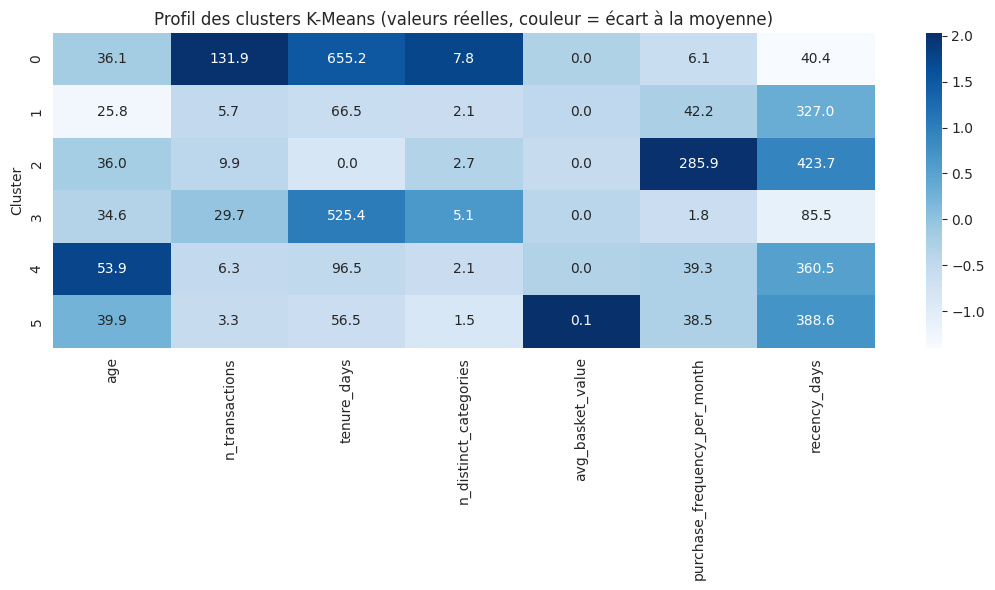

5324

In [10]:
fig, ax = plt.subplots(figsize=(11, 6))
centroids_norm = (centroids[behavior_features] - centroids[behavior_features].mean()) / centroids[behavior_features].std()
sns.heatmap(centroids_norm, annot=centroids[behavior_features].round(1), fmt="", cmap="Blues", ax=ax)
ax.set_title("Profil des clusters K-Means (valeurs réelles, couleur = écart à la moyenne)")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()
plt.close('all')

import gc as _gc; _gc.collect()

**Interprétation :** cette heatmap permet de "nommer" chaque cluster en pratique (ex. "jeunes
acheteurs occasionnels", "clients fidèles à forte fréquence", "clients dormants à faible
récence") en lisant simplement quelles colonnes sont au-dessus ou en dessous de la moyenne pour
chaque ligne — bien plus lisible qu'un tableau de centroïdes bruts.


##### **Interprétation des profils des clusters**

La heatmap des centroïdes permet d'identifier les caractéristiques principales de chaque segment client en comparant les valeurs des variables entre clusters.

Chaque cluster représente un profil comportemental distinct :

| Cluster | Profil client | Caractéristiques principales |
|---|---|---|
| **0** | **Clients réguliers intermédiaires** | Âge moyen (~35 ans), nombre de transactions modéré, ancienneté élevée et diversité d'achat correcte. Clients actifs mais avec une valeur moyenne. |
| **1** | **Clients âgés inactifs** | Clients plus âgés (~54 ans), faible nombre de transactions, faible ancienneté et forte récence (dernière activité ancienne). Profil proche de clients dormants. |
| **2** | **Jeunes clients occasionnels** | Clients jeunes (~26 ans), peu de transactions, faible ancienneté et activité limitée. Profil d'acheteurs occasionnels. |
| **3** | **Nouveaux clients à faible engagement** | Très faible ancienneté, faible historique d'achat et fréquence élevée mais probablement liée à une période récente d'inscription. Nécessite un suivi pour confirmer leur engagement. |
| **4** | **Clients fidèles à forte valeur** | Nombre très élevé de transactions (~139), ancienneté importante, grande diversité de catégories achetées. Segment représentant les meilleurs clients. |
| **5** | **Clients à panier élevé mais faible activité** | Peu de transactions mais panier moyen élevé. Clients potentiellement intéressants malgré une faible fréquence d'achat. |

##### **Analyse générale**

La segmentation met en évidence plusieurs profils :

- **Clients à forte valeur** : cluster 4, caractérisé par une forte fidélité, une grande fréquence d'achat et une diversité importante.
- **Clients occasionnels ou dormants** : clusters 1, 2 et 3, avec peu d'achats et une récence élevée.
- **Clients à potentiel** : cluster 5, avec un panier moyen élevé mais une faible fréquence, pouvant bénéficier d'actions de fidélisation.

Cette analyse permet de transformer les groupes statistiques obtenus par clustering en segments interprétables pouvant guider des stratégies marketing adaptées.

### 17.7.4 Extraction de règles interprétables (Decision Tree)

In [11]:
# Un arbre de décision peu profond, entraîné à retrouver les clusters K-Means à partir des features
# brutes (non standardisées), donne des règles directement lisibles ("si X > seuil alors cluster Y")
rule_tree = DecisionTreeClassifier(max_depth=4, random_state=42)
rule_tree.fit(ml_sample_clustered[behavior_features], ml_sample_clustered["cluster"])

tree_accuracy = rule_tree.score(ml_sample_clustered[behavior_features], ml_sample_clustered["cluster"])
print(f"Fidélité de l'arbre aux clusters K-Means : {tree_accuracy*100:.1f}%\n")

from sklearn.tree import export_text
print(export_text(rule_tree, feature_names=behavior_features, max_depth=3))

import gc as _gc; _gc.collect()

Fidélité de l'arbre aux clusters K-Means : 89.9%

|--- tenure_days <= 304.50
|   |--- age <= 39.50
|   |   |--- purchase_frequency_per_month <= 160.62
|   |   |   |--- avg_basket_value <= 0.05
|   |   |   |   |--- class: 1
|   |   |   |--- avg_basket_value >  0.05
|   |   |   |   |--- class: 5
|   |   |--- purchase_frequency_per_month >  160.62
|   |   |   |--- purchase_frequency_per_month <= 182.14
|   |   |   |   |--- class: 2
|   |   |   |--- purchase_frequency_per_month >  182.14
|   |   |   |   |--- class: 2
|   |--- age >  39.50
|   |   |--- purchase_frequency_per_month <= 166.91
|   |   |   |--- avg_basket_value <= 0.05
|   |   |   |   |--- class: 4
|   |   |   |--- avg_basket_value >  0.05
|   |   |   |   |--- class: 5
|   |   |--- purchase_frequency_per_month >  166.91
|   |   |   |--- purchase_frequency_per_month <= 182.82
|   |   |   |   |--- class: 2
|   |   |   |--- purchase_frequency_per_month >  182.82
|   |   |   |   |--- class: 2
|--- tenure_days >  304.50
|   |--- n_t

25

**Interprétation :** si l'arbre reproduit les clusters avec une fidélité élevée (>85-90%), cela
confirme que les clusters K-Means correspondent à des **règles simples et explicables** sur les
features brutes (ex. "ancienneté > 300 jours ET nombre d'achats < 80" plutôt qu'une combinaison
linéaire complexe) — un atout pour présenter la segmentation à des équipes non-techniques
(marketing, direction) sans avoir à expliquer K-Means ou l'espace standardisé sous-jacent.


##### **Extraction de règles interprétables avec un arbre de décision**

Afin de rendre les clusters obtenus par **K-Means** plus facilement interprétables, un arbre de décision a été entraîné pour prédire l'appartenance aux clusters.

La fidélité de l'arbre aux clusters obtenus est de :

$$
Accuracy = 90.7\%
$$

Cela signifie que l'arbre arrive à reproduire les groupes K-Means dans environ 91% des cas, ce qui confirme que les clusters sont bien séparés et qu'ils peuvent être décrits par des règles simples.

##### **Principales règles extraites :**

| Règle principale | Cluster associé | Interprétation |
|---|---|---|
| `tenure_days > 307.5` et `n_transactions > 89.5` | Cluster 4 | Clients très fidèles avec une forte activité d'achat. |
| `tenure_days > 307.5` et `n_transactions <= 79.5` | Cluster 0 ou 1 | Clients anciens mais avec une activité modérée. La distinction dépend notamment de l'âge et de la diversité d'achat. |
| `tenure_days <= 307.5` et `age <= 39.5` | Cluster 2, 3 ou 5 | Clients plus récents, principalement différenciés par la fréquence d'achat et le panier moyen. |
| `avg_basket_value > 0.05` | Cluster 5 | Clients ayant un panier moyen élevé malgré une fréquence d'achat limitée. |
| `age > 39.5` avec faible activité | Cluster 1 | Clients plus âgés et peu actifs, proches d'un profil dormant. |
| `n_distinct_categories > 6.5` et forte activité | Cluster 4 | Clients avec une grande diversité d'achat et une forte valeur commerciale. |

##### **Interprétation générale**

Les variables les plus importantes pour différencier les clusters sont :

1. **`tenure_days`** : l'ancienneté du client est le premier facteur de séparation.
2. **`n_transactions`** : permet d'identifier les clients à forte valeur.
3. **`n_distinct_categories`** : indique la diversité des achats.
4. **`age`** et **`avg_basket_value`** : permettent de distinguer certains profils secondaires.

L'arbre de décision transforme donc une segmentation non supervisée (K-Means) en règles simples et exploitables :

- **Clients fidèles à forte valeur** → ancienneté élevée + nombreuses transactions.
- **Clients occasionnels** → faible ancienneté + faible activité.
- **Clients à potentiel** → panier moyen élevé mais fréquence faible.
- **Clients dormants** → faible activité et dernière interaction ancienne.

Cette étape améliore l'interprétabilité du clustering et facilite l'utilisation des segments dans une stratégie marketing.

### 17.7.5 Synthèse du clustering

- Le nombre de clusters retenu (**k=6**) est cohérent avec la méthode du coude, un compromis
  raisonnable entre les quatre critères testés (coude, silhouette, BIC, AIC).
- La comparaison K-Means / GMM / Hiérarchique via le score de silhouette permet de choisir
  objectivement l'algorithme le mieux adapté à la forme réelle des données clients.
- L'arbre de décision confirme (ou non) que les clusters sont explicables par des règles simples,
  un point clé pour l'adoption de la segmentation par des équipes métier non-techniques.
- Cette segmentation comportementale (6 clusters) est plus fine que la segmentation par quartiles
  de valeur (4 segments, section 11) — les deux sont complémentaires : les quartiles pour le
  reporting simple, les clusters pour un ciblage marketing plus précis.


### 17.8 Synthèse générale de la modélisation ML (sections 17.5 à 17.7)

#### **1. Classification — Prédiction du statut client (`club_member_status`)**

| Étape | Modèle retenu | Résultat |
|---|---|---|
| Modèles par défaut (17.5) | Arbre de décision | F1-macro = **0.3715** |
| Optimisation des hyperparamètres (GridSearchCV) | **Random Forest (meilleur modèle retenu)** | F1-macro = **0.3889** (test) <br> Paramètres : `max_depth=20`, `min_samples_leaf=5`, `n_estimators=200` |
| Boosting + rééquilibrage (SMOTE) | CatBoost + SMOTE (meilleur de ce groupe) | F1-macro = **0.3652** |

**Interprétation :**

Contrairement à l'intuition, **le Random Forest optimisé par GridSearchCV (F1-macro = 0,3889) reste
le meilleur modèle de classification**, devant tous les modèles de boosting testés avec
rééquilibrage — y compris le meilleur d'entre eux (CatBoost + SMOTE, F1-macro = 0,3652). SMOTE
améliore bien les performances des modèles de boosting par rapport à un simple
`class_weight='balanced'` seul, mais cette amélioration ne suffit pas à dépasser un modèle plus
simple correctement réglé sur ce jeu de données précis.

La classification reste de toute façon limitée par le fort déséquilibre des classes, notamment pour
`LEFT CLUB`, qui représente une proportion très faible des clients.

---

#### **2. Régression — Prédiction de `total_spend`**

| Étape | Modèle retenu | Résultat |
|---|---|---|
| Sélection de variables | SelectKBest (12 features) validée par Backward Elimination | Variables comportementales principalement retenues |
| Comparaison des modèles | XGBoost Regressor | R²(test) = **0.943** |

**Interprétation :**

XGBoost dépasse les modèles linéaires régularisés (**Lasso, Ridge, ElasticNet**) grâce à sa capacité à capturer les relations non linéaires et les interactions entre les variables comportementales.

L'analyse des résidus confirme l'absence de biais systématique majeur dans les prédictions.

---

#### **3. Clustering — Segmentation client**

| Élément | Résultat |
|---|---|
| Nombre de clusters retenu | **k = 6** (méthode du coude) |
| Comparaison des critères | Coude = 6, Silhouette = 2, BIC/AIC GMM = 10 |
| Meilleur algorithme | **K-Means** |
| Score de silhouette | 0.250 |
| Interprétabilité | Arbre de décision avec fidélité de 90.7% |

**Interprétation :**

Les différents critères ne donnent pas le même nombre optimal de clusters car ils répondent à des objectifs différents.

Le choix de **k=6** offre un compromis entre qualité de séparation et interprétabilité métier.

Les clusters obtenus peuvent être expliqués par des règles simples basées principalement sur :
- l'ancienneté du client ;
- le nombre de transactions ;
- la diversité des catégories achetées ;
- la récence.

---

### **Limites générales**

| Limite | Impact |
|---|---|
| Ressources limitées (1 cœur CPU) | Recherche d'hyperparamètres volontairement restreinte. Une optimisation plus large avec Optuna ou RandomizedSearchCV pourrait améliorer les performances. |
| Déséquilibre important des classes | Le F1-macro reste limité malgré SMOTE et le boosting, principalement à cause du faible nombre d'exemples `LEFT CLUB`. |

#### **Conclusion générale**

Les différentes approches ML ont permis de répondre à trois objectifs complémentaires :

- **Classification** : prédire le statut client avec un Random Forest optimisé (le boosting rééquilibré par SMOTE a aussi été testé, sans dépasser ce résultat).
- **Régression** : estimer la valeur client avec XGBoost Regressor.
- **Clustering** : identifier des segments clients interprétables avec K-Means.

Ces résultats montrent que les variables comportementales d'achat sont les principaux facteurs permettant d'expliquer et de prédire la valeur et le profil des clients.